# Autocorrelación Espacial: Moran's I y LISA (v2)

## Introducción

**Qué se busca:** este notebook aplica la metodología de autocorrelación espacial de
`07_MatrizCorrelacion` del libro (Moran's I global y LISA) a dos fuentes de datos ya
construidas en notebooks anteriores de este proyecto, en vez de generar datos nuevos:

- **Parte A:** los 491 polígonos de altiplano ya tipificados
  (`02_clustering_espacial_altiplanos_v2.ipynb`). Pregunta: *¿los altiplanos con perfil
  morfométrico similar (altitud, pendiente, relieve) están geográficamente agrupados, o el
  patrón es esencialmente aleatorio en el espacio?*
- **Parte B:** los residuos del modelo de regresión logística NO espacializada sobre
  píxeles (`03_regresion_no_espacial_raster_v2.ipynb`). Pregunta: *¿el modelo deja patrón
  espacial sin explicar en sus errores?*

**Método del libro utilizado:** `07_MatrizCorrelacion` — matriz de pesos espaciales (KNN),
Índice de Moran global, Gráfico de Moran, e Indicadores Locales de Asociación Espacial
(LISA / `esda.Moran_Local`). La vecindad en ambas partes se define por KNN (nunca deja
observaciones sin vecinos, a diferencia de DistanceBand — ver la nota explícita en la
sección [A2]).

**Cambios respecto a la versión anterior (`04_autocorrelacion_espacial.ipynb`):** convertido
a `.ipynb` real; se agregó una breve sección de exploración de datos en cada parte (aunque
las variables de la Parte A ya se exploraron en `01_..._v2`/`02_..._v2`, se repite aquí un
resumen mínimo por completitud, siguiendo la skill del proyecto); lee las capas `_v2`
exportadas por los notebooks 02 y usa el mismo pipeline determinista para reconstruir la
muestra de píxeles de la Parte B.


## [0] Configuración e importación de librerías


In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import reproject, Resampling

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

from libpysal.weights import KNN
import esda
from splot.esda import plot_moran, lisa_cluster, moran_scatterplot

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

CARPETA_RASTER = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Raster\50m_UTM\Analisis"
CARPETA_CAPAS = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Capas"
CARPETA_RESULTADOS = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados"
CARPETA_FIGURAS = os.path.join(CARPETA_RESULTADOS, "04_autocorrelacion_espacial_v2")
os.makedirs(CARPETA_FIGURAS, exist_ok=True)

SEMILLA = 42

print(f"Carpeta de figuras de este notebook: {CARPETA_FIGURAS}")


Carpeta de figuras de este notebook: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\04_autocorrelacion_espacial_v2


# PARTE A — Autocorrelación espacial de los 491 altiplanos


## [A1] Cargar la capa ya tipificada

Se reutiliza el GeoPackage exportado por `02_clustering_espacial_altiplanos_v2.ipynb`
(`altiplanos_clustering_espacial_v2.gpkg`). Al ser GeoPackage (no shapefile), los nombres de
columna con tilde se leen correctamente sin necesitar el workaround del `.dbf`.


In [2]:
gdf = gpd.read_file(f"{CARPETA_RESULTADOS}\\altiplanos_clustering_espacial_v2.gpkg")
print(f"Poligonos cargados: {len(gdf)}")
print(f"Columnas: {list(gdf.columns)}")


Poligonos cargados: 491
Columnas: ['Altitud_X', 'Altitud_St', 'Relieve_X', 'Relieve_St', 'Pend_X', 'Pend_St', 'Num', 'Alt_90', 'Alt_50', 'Alt_10', 'Geo_Value', 'Geología', 'Área', 'Rel_90', 'Rel_50', 'Rel_10', 'Slp_90', 'Slp_50', 'Slp_10', 'Latitud', 'Lat_Max', 'Lat_Min', 'Longitud', 'Lon_Max', 'Lon_Min', 'cluster_mejor_knn', 'cluster_mejor_distancia', 'cluster_espacial', 'cluster_sin_restriccion', 'geometry']


## [A2] Exploración de datos (Parte A)

Resumen mínimo de las tres variables morfométricas usadas en el análisis de autocorrelación
(ya exploradas a fondo en `01_clustering_altiplanos_v2.ipynb`, se repite aquí por
completitud). N=491 polígonos, ninguno excluido (datos vectoriales sin NoData).


In [3]:
print(f"N = {len(gdf)} poligonos, sin exclusiones.")
gdf[["Altitud_X", "Pend_X", "Relieve_X"]].describe().T


N = 491 poligonos, sin exclusiones.


,count,mean,std,min,25%,50%,75%,max
Altitud_X,491.0,1258.583772,725.172427,412.92700,671.57250,1017.7000,1625.00000,3608.2600
Pend_X,491.0,11.977463,1.956846,6.80707,10.52895,12.1265,13.30865,18.2158
Relieve_X,491.0,44.420052,6.890411,26.68940,39.14650,44.7290,48.95435,76.2206


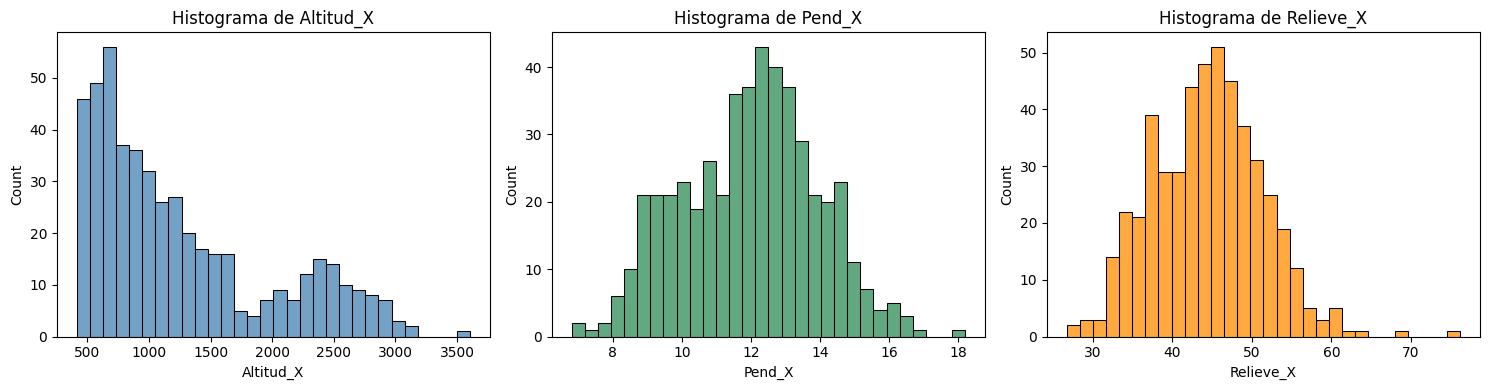

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var, color in zip(axes, ["Altitud_X", "Pend_X", "Relieve_X"], ["steelblue", "seagreen", "darkorange"]):
    sns.histplot(gdf[var], bins=30, color=color, ax=ax)
    ax.set_title(f"Histograma de {var}")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "00_histogramas_variables_parteA.png"), dpi=150)
plt.show()


## [A3] Matriz de pesos espaciales (KNN)

Como los polígonos no se tocan entre sí, no se puede usar contigüidad tipo Queen/Rook. Se
usa KNN con **k=6**, el mismo valor que usa el libro en su propio ejemplo de cuencas
colombianas para esta sección. Por construcción, **KNN nunca deja polígonos sin vecinos**
(a diferencia de DistanceBand, explorado en `02_clustering_espacial_altiplanos_v2.ipynb`).


In [5]:
w = KNN.from_dataframe(gdf, k=6)
w.transform = "r"
print(f"Matriz de pesos KNN(k=6) construida sobre {len(gdf)} centroides.")
print(f"Poligonos sin vecinos (islas): {len(w.islands)} (KNN siempre da exactamente k vecinos a cada observacion)")


Matriz de pesos KNN(k=6) construida sobre 491 centroides.
Poligonos sin vecinos (islas): 0 (KNN siempre da exactamente k vecinos a cada observacion)


## [A4] Índice de Moran global

Un único número por variable que resume qué tan agrupados (vs. aleatorios) están sus
valores en el espacio.

**Ventajas / desventajas del Índice de Moran global:**
- (+) Resume todo el mapa en un solo número comparable entre variables.
- (-) No dice **dónde** están los agrupamientos (para eso se necesita LISA, sección [A5]).


In [6]:
variables_moran = ["Altitud_X", "Pend_X", "Relieve_X"]
resultados_moran = {}

np.random.seed(SEMILLA)  # esda.Moran no acepta seed directamente; se fija la semilla global antes
for var in variables_moran:
    mi = esda.Moran(gdf[var], w, permutations=999)
    resultados_moran[var] = mi
    print(f"{var}: I={mi.I:.4f}  p_sim={mi.p_sim:.4f}  z={mi.z_sim:.2f}")


Altitud_X: I=0.9200  p_sim=0.0010  z=37.93
Pend_X: I=0.5893  p_sim=0.0010  z=24.07
Relieve_X: I=0.4841  p_sim=0.0010  z=19.47


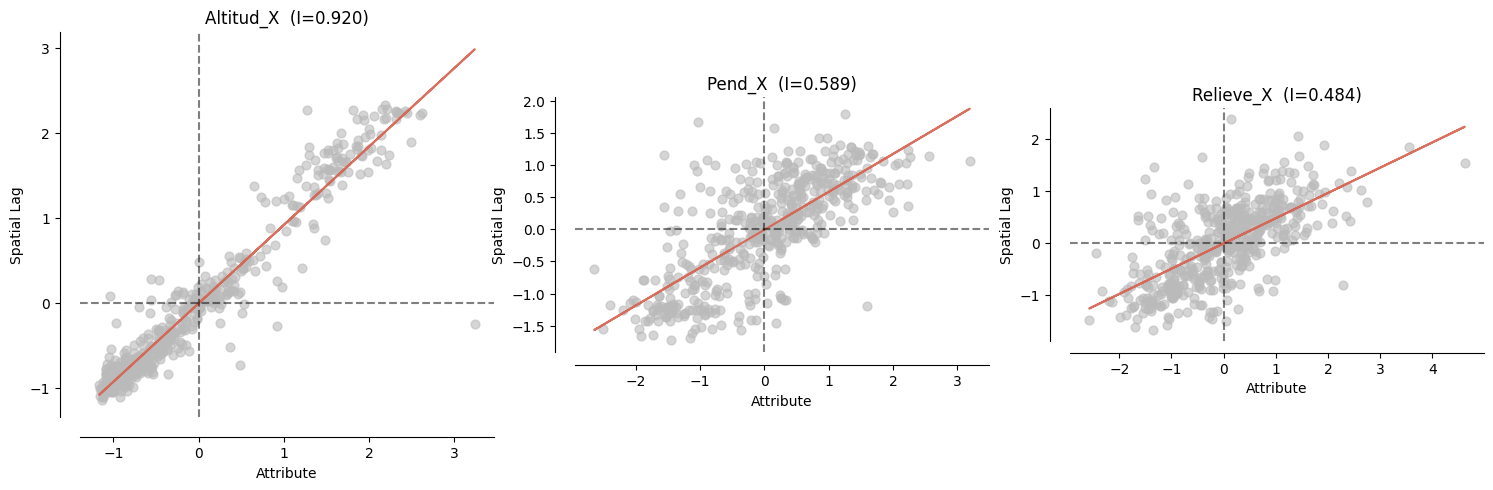

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, var in zip(axes, variables_moran):
    moran_scatterplot(resultados_moran[var], ax=ax)
    ax.set_title(f"{var}  (I={resultados_moran[var].I:.3f})")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "01_moran_scatterplot_poligonos.png"), dpi=150)
plt.show()


**Interpretación:** los tres valores de Moran's I son altos y estadísticamente
significativos (p=0.001 con 999 permutaciones), lo que indica que los altiplanos NO se
distribuyen al azar respecto a su morfometría: altiplanos con altitud/pendiente/relieve
similar tienden a estar geográficamente cerca unos de otros.


## [A5] LISA: ¿dónde están los agrupamientos?

Se identifica qué altiplanos específicos forman parte de un clúster local significativo
(alto rodeado de altos, bajo rodeado de bajos) y cuáles son valores atípicos espaciales,
para la variable con el Moran's I más alto (`Altitud_X`).


In [8]:
lisa = esda.Moran_Local(gdf["Altitud_X"], w, permutations=999, seed=SEMILLA)

gdf["Altitud_X_Is"] = lisa.Is
gdf["Altitud_X_quadrant"] = lisa.q
gdf["Altitud_X_p_sim"] = lisa.p_sim
gdf["Altitud_X_significativo"] = lisa.p_sim < 0.05

print("Distribucion de cuadrantes LISA (1=HH, 2=LH, 3=LL, 4=HL):")
print(pd.Series(lisa.q).value_counts().sort_index())
print(f"\nPoligonos con cluster local significativo (p<0.05): {gdf['Altitud_X_significativo'].sum()} de {len(gdf)}")


Distribucion de cuadrantes LISA (1=HH, 2=LH, 3=LL, 4=HL):
1    172
2     22
3    284
4     13
Name: count, dtype: int64

Poligonos con cluster local significativo (p<0.05): 284 de 491


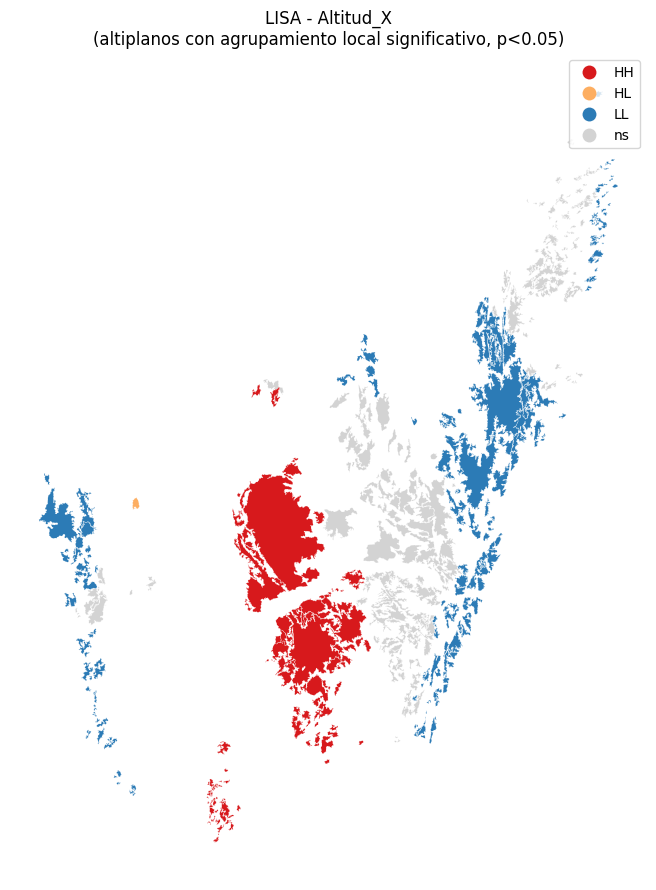

In [9]:
fig, ax = plt.subplots(1, figsize=(9, 9))
lisa_cluster(lisa, gdf, ax=ax)
ax.set_title("LISA - Altitud_X\n(altiplanos con agrupamiento local significativo, p<0.05)")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "02_lisa_cluster_altitud_poligonos.png"), dpi=150)
plt.show()


### [A5b] Versión cartográfica del mapa LISA (plantilla con hillshade/norte/escala)

Misma figura de la sección [A5], redibujada con la plantilla cartográfica estándar del
proyecto (`plantilla_mapas.py`). Esta celda solo llama a la capa ya calculada (`gdf`/`lisa`)
— no repite ningún cálculo del análisis.

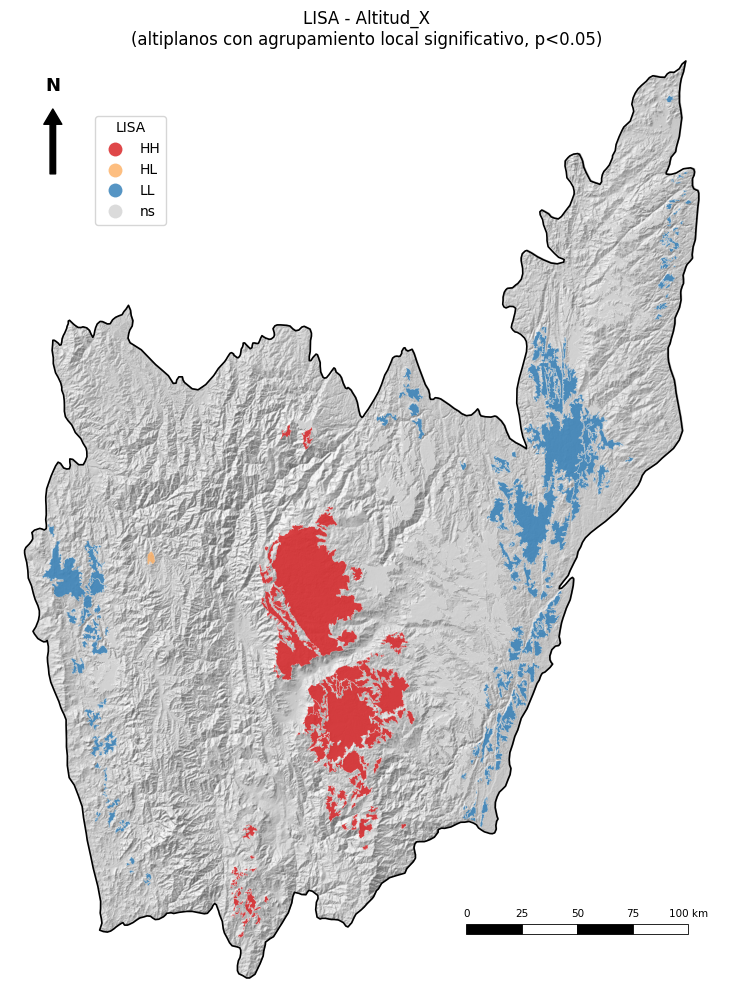

In [10]:
from plantilla_mapas import aplicar_plantilla_mapa, posicionar_leyenda, CARPETA_IMAGENES

CARPETA_IMAGENES_NB = os.path.join(CARPETA_IMAGENES, "04_autocorrelacion_espacial_v2")
os.makedirs(CARPETA_IMAGENES_NB, exist_ok=True)

fig, ax = plt.subplots(1, figsize=(10, 10))
ancla = aplicar_plantilla_mapa(ax, extent_de=gdf)
lisa_cluster(lisa, gdf, ax=ax, alpha=0.8, zorder=5, legend_kwds=posicionar_leyenda(ax, ancla, titulo="LISA"))
ax.set_title("LISA - Altitud_X\n(altiplanos con agrupamiento local significativo, p<0.05)")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_IMAGENES_NB, "02_lisa_cluster_altitud_poligonos.png"), dpi=150)
plt.show()


## [A6] Exportar capa de respaldo (Parte A)


In [11]:
ruta_backup_a = os.path.join(CARPETA_RESULTADOS, "altiplanos_moran_lisa_v2.gpkg")
gdf.to_file(ruta_backup_a, driver="GPKG")
print(f"Backup Parte A guardado en: {ruta_backup_a}")


Backup Parte A guardado en: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\altiplanos_moran_lisa_v2.gpkg


# PARTE B — Diagnóstico espacial de los residuos del modelo raster


## [B1] Recrear la muestra de píxeles y el modelo (idéntico a `03_regresion_no_espacial_raster_v2.ipynb`)

Se reconstruye exactamente la misma muestra de 300,000 píxeles y el mismo modelo de
regresión logística del notebook anterior (misma `SEMILLA=42`), para poder calcular sus
residuos.


In [12]:
t0 = time.time()

with rasterio.open(f"{CARPETA_RASTER}\\DEM_NA_50.tif") as src:
    altitud = src.read(1).astype(np.float32)
    dem_nodata = src.nodata
    ref_transform = src.transform
    ref_crs = src.crs
    ref_shape = (src.height, src.width)
mascara_dem_valida = altitud != dem_nodata

with rasterio.open(f"{CARPETA_RASTER}\\Altiplanos.tif") as src:
    altiplano_original = src.read(1)
    altiplano_nodata = src.nodata
    altiplano_transform = src.transform
    altiplano_crs = src.crs

altiplano_alineado = np.zeros(ref_shape, dtype=np.uint8)
reproject(
    source=altiplano_original, destination=altiplano_alineado,
    src_transform=altiplano_transform, src_crs=altiplano_crs,
    dst_transform=ref_transform, dst_crs=ref_crs,
    resampling=Resampling.nearest, src_nodata=altiplano_nodata, dst_nodata=0,
)

predictores_archivos = {
    "Altitud": "DEM_NA_50.tif", "Pendiente": "Slp_NA_50.tif", "Relieve_5": "Rel_NA_5.tif",
    "ResidMedia_5": "Resta_Alt_NA_Alt_mean_5.tif", "ResidMedia_10": "Resta_Alt_NA_Alt_mean_10.tif",
    "ResidMin_3": "Resta_Alt_NA_Alt_min_3.tif", "ResidMin_10": "Resta_Alt_NA_Alt_min_10.tif",
    "ResidMin_50": "Resta_Alt_NA_Alt_min_50.tif", "ResidMin_100": "Resta_Alt_NA_Alt_min_100.tif",
    "ResidMax_3": "Resta_Alt_max_3_Alt_NA.tif", "ResidMax_10": "Resta_Alt_max_10_Alt_NA.tif",
    "ResidMax_50": "Resta_Alt_max_50_Alt_NA.tif", "ResidMax_100": "Resta_Alt_max_100_Alt_NA.tif",
    "DifMedia_3_10": "Resta_Alt_mean_3_10.tif",
    "PendResidMedia_5": "Slp_Resta_Alt_NA_Alt_mean_5.tif", "PendResidMedia_10": "Slp_Resta_Alt_NA_Alt_mean_10.tif",
    "PendDifMedia_3_10": "Slp_Resta_Alt_mean_3_10.tif", "PendDifMedia_5_10": "Slp_Resta_Alt_mean_5_10.tif",
}

datos = {}
mascara_valida = mascara_dem_valida.copy()
for nombre, archivo in predictores_archivos.items():
    with rasterio.open(f"{CARPETA_RASTER}\\{archivo}") as src:
        banda = src.read(1).astype(np.float32)
        nod = src.nodata
        if nod is not None and np.isnan(nod):
            valido_capa = ~np.isnan(banda)
        elif nod is not None:
            valido_capa = banda != nod
        else:
            valido_capa = np.ones_like(banda, dtype=bool)
    datos[nombre] = banda
    mascara_valida &= valido_capa

idx_validos = np.flatnonzero(mascara_valida)
variables_predictoras = list(predictores_archivos.keys())

tabla = pd.DataFrame({nombre: banda.ravel()[idx_validos] for nombre, banda in datos.items()})
y_altiplano = (altiplano_alineado == 1) & mascara_valida
tabla["Altiplano"] = y_altiplano.ravel()[idx_validos].astype(int)

filas, columnas = np.unravel_index(idx_validos, ref_shape)
xs, ys = rasterio.transform.xy(ref_transform, filas, columnas)
tabla["X"] = np.array(xs)
tabla["Y"] = np.array(ys)

print(f"Tabla de pixeles reconstruida: {tabla.shape}  t={time.time()-t0:.1f}s")


Tabla de pixeles reconstruida: (24783966, 21)  t=10.2s


In [13]:
N_MUESTRA = 300_000
muestra = tabla.sample(n=N_MUESTRA, random_state=SEMILLA)
X = muestra[variables_predictoras]
y = muestra["Altiplano"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEMILLA, stratify=y)
escalador = StandardScaler()
X_train_s = escalador.fit_transform(X_train)

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train_s, y_train)

print(f"Modelo reajustado sobre {len(X_train):,} filas de entrenamiento "
      f"(identico a 03_regresion_no_espacial_raster_v2.ipynb).")


Modelo reajustado sobre 210,000 filas de entrenamiento (identico a 03_regresion_no_espacial_raster_v2.ipynb).


## [B2] Exploración de datos (Parte B)

**N y área de la muestra usada en el diagnóstico:** la muestra de 300,000 píxeles se extrae
de una población de 24,783,966 píxeles válidos (documentado en detalle en
`03_regresion_no_espacial_raster_v2.ipynb`, sección de exploración de datos). Aquí se
calcula el residuo de respuesta y se explora su distribución antes de construir la matriz
de pesos espaciales.

**Qué se busca:** el libro (`09_SpatialRegression`) diagnostica autocorrelación espacial
sobre los residuos de un modelo OLS. La regresión logística no tiene un residuo "OLS"
nativo; se usa en su lugar el **residuo de respuesta** (`y - probabilidad predicha`):
positivo donde el modelo SUBestima la probabilidad de ser altiplano, negativo donde la
SOBREestima.


In [14]:
X_muestra_s = escalador.transform(X)
prob_muestra = modelo.predict_proba(X_muestra_s)[:, 1]
residuo = y.values - prob_muestra

muestra = muestra.copy()
muestra["prob_predicha"] = prob_muestra
muestra["residuo"] = residuo

print(f"N de la muestra usada en el diagnostico: {len(muestra):,} de {len(tabla):,} pixeles totales "
      f"({100*len(muestra)/len(tabla):.2f}% de la poblacion)")
print(f"Residuo: media={residuo.mean():.4f}  desv.est.={residuo.std():.4f}")
print(f"Rango: [{residuo.min():.3f}, {residuo.max():.3f}]")


N de la muestra usada en el diagnostico: 300,000 de 24,783,966 pixeles totales (1.21% de la poblacion)
Residuo: media=-0.0002  desv.est.=0.2449
Rango: [-0.990, 1.000]


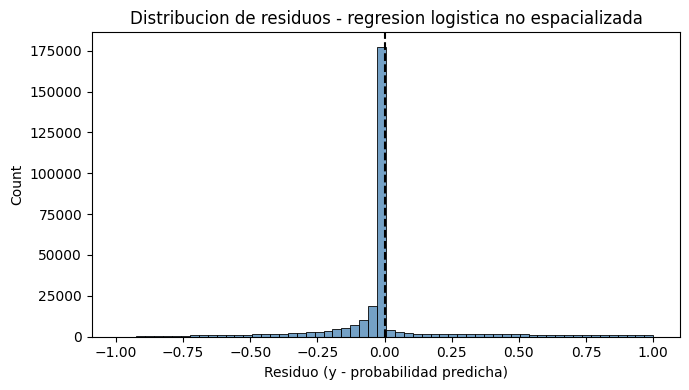

In [15]:
plt.figure(figsize=(7, 4))
sns.histplot(residuo, bins=60, color="steelblue")
plt.axvline(0, color="k", linestyle="--")
plt.xlabel("Residuo (y - probabilidad predicha)")
plt.title("Distribucion de residuos - regresion logistica no espacializada")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "03_histograma_residuos.png"), dpi=150)
plt.show()


## [B3] Matriz de pesos espaciales sobre la muestra de píxeles

Se construye una vecindad KNN entre los 300,000 puntos-píxel de la muestra, usando sus
coordenadas reales. Se usa la muestra completa de 300,000 en vez de un subconjunto más
pequeño porque, en una prueba preliminar, el valor de Moran's I aumentó con el tamaño de la
muestra (vecinos "k más cercanos" quedan a una distancia real menor con más puntos).


In [16]:
t1 = time.time()
coords_muestra = muestra[["X", "Y"]].values
w_pixeles = KNN.from_array(coords_muestra, k=8)
w_pixeles.transform = "r"
print(f"Matriz de pesos KNN(k=8) construida sobre {len(muestra):,} pixeles en {time.time()-t1:.1f}s")


Matriz de pesos KNN(k=8) construida sobre 300,000 pixeles en 3.5s


## [B4] Índice de Moran global de los residuos


In [17]:
np.random.seed(SEMILLA)
t1 = time.time()
mi_residuo = esda.Moran(muestra["residuo"], w_pixeles, permutations=999)
print(f"Moran's I de los residuos: I={mi_residuo.I:.4f}  p_sim={mi_residuo.p_sim:.4f}  z={mi_residuo.z_sim:.2f}")
print(f"(calculado en {time.time()-t1:.1f}s)")


Moran's I de los residuos: I=0.6101  p_sim=0.0010  z=676.43
(calculado en 13.7s)


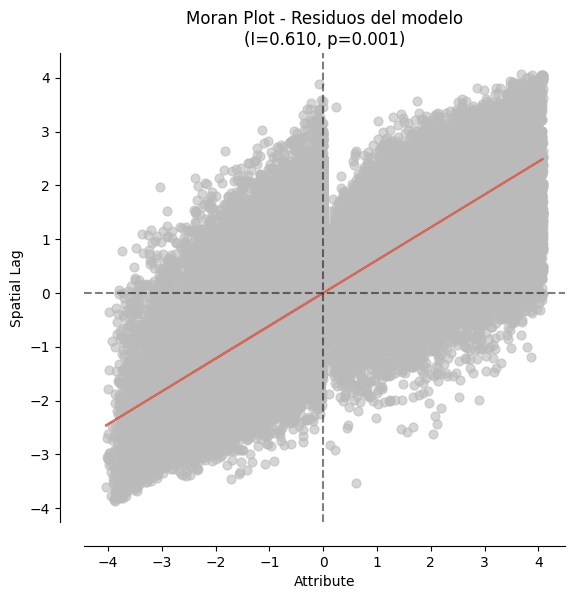

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
moran_scatterplot(mi_residuo, ax=ax)
ax.set_title(f"Moran Plot - Residuos del modelo\n(I={mi_residuo.I:.3f}, p={mi_residuo.p_sim:.3f})")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "04_moran_scatterplot_residuos_raster.png"), dpi=150)
plt.show()


**Interpretación:** un Moran's I positivo y significativo en los residuos confirma que el
modelo NO espacializado **deja patrón espacial sin explicar**: los píxeles donde el modelo
se equivoca no están distribuidos al azar, sino agrupados geográficamente — el diagnóstico
que el libro usa para justificar el paso hacia modelos espaciales explícitos (`10_SAR`).


## [B5] LISA de los residuos: ¿dónde falla más el modelo?


In [19]:
t1 = time.time()
lisa_residuo = esda.Moran_Local(muestra["residuo"].values, w_pixeles, permutations=199, seed=SEMILLA, n_jobs=-1)
print(f"LISA de residuos calculado en {time.time()-t1:.1f}s")

muestra["residuo_Is"] = lisa_residuo.Is
muestra["residuo_quadrant"] = lisa_residuo.q
muestra["residuo_p_sim"] = lisa_residuo.p_sim
muestra["residuo_significativo"] = lisa_residuo.p_sim < 0.05

print(f"\nPixeles con residuo local significativo (p<0.05): {muestra['residuo_significativo'].sum():,} de {len(muestra):,}")


LISA de residuos calculado en 64.6s

Pixeles con residuo local significativo (p<0.05): 75,854 de 300,000


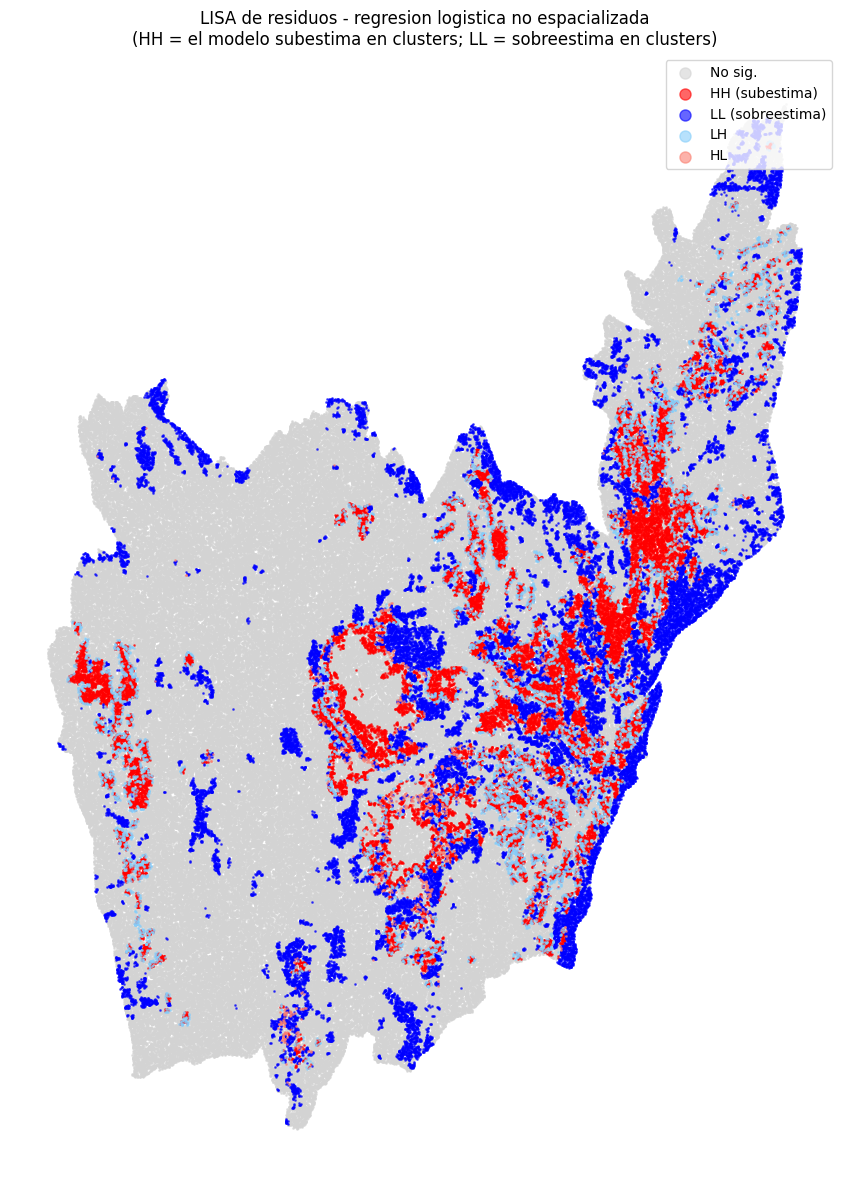

In [20]:
sig = muestra["residuo_significativo"].values
quad = muestra["residuo_quadrant"].values
etiqueta = np.where(~sig, "No sig.", np.where(quad == 1, "HH (subestima)",
             np.where(quad == 3, "LL (sobreestima)", np.where(quad == 2, "LH", "HL"))))

colores = {"No sig.": "lightgrey", "HH (subestima)": "red", "LL (sobreestima)": "blue",
           "LH": "lightskyblue", "HL": "salmon"}

fig, ax = plt.subplots(figsize=(10, 12))
for categoria, color in colores.items():
    mask_cat = etiqueta == categoria
    ax.scatter(muestra["X"].values[mask_cat], muestra["Y"].values[mask_cat],
               s=1, c=color, label=categoria, alpha=0.6)
ax.set_title("LISA de residuos - regresion logistica no espacializada\n"
             "(HH = el modelo subestima en clusters; LL = sobreestima en clusters)")
ax.set_axis_off()
ax.set_aspect("equal")
ax.legend(markerscale=8, loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "05_lisa_residuos_raster.png"), dpi=150)
plt.show()


### [B5b] Versión cartográfica del mapa LISA de residuos (plantilla con hillshade/norte/escala)

Misma figura de la sección [B5], redibujada con la plantilla cartográfica estándar del
proyecto (`plantilla_mapas.py`). Esta celda solo llama a los datos ya calculados
(`muestra`) — no repite ningún cálculo del análisis.

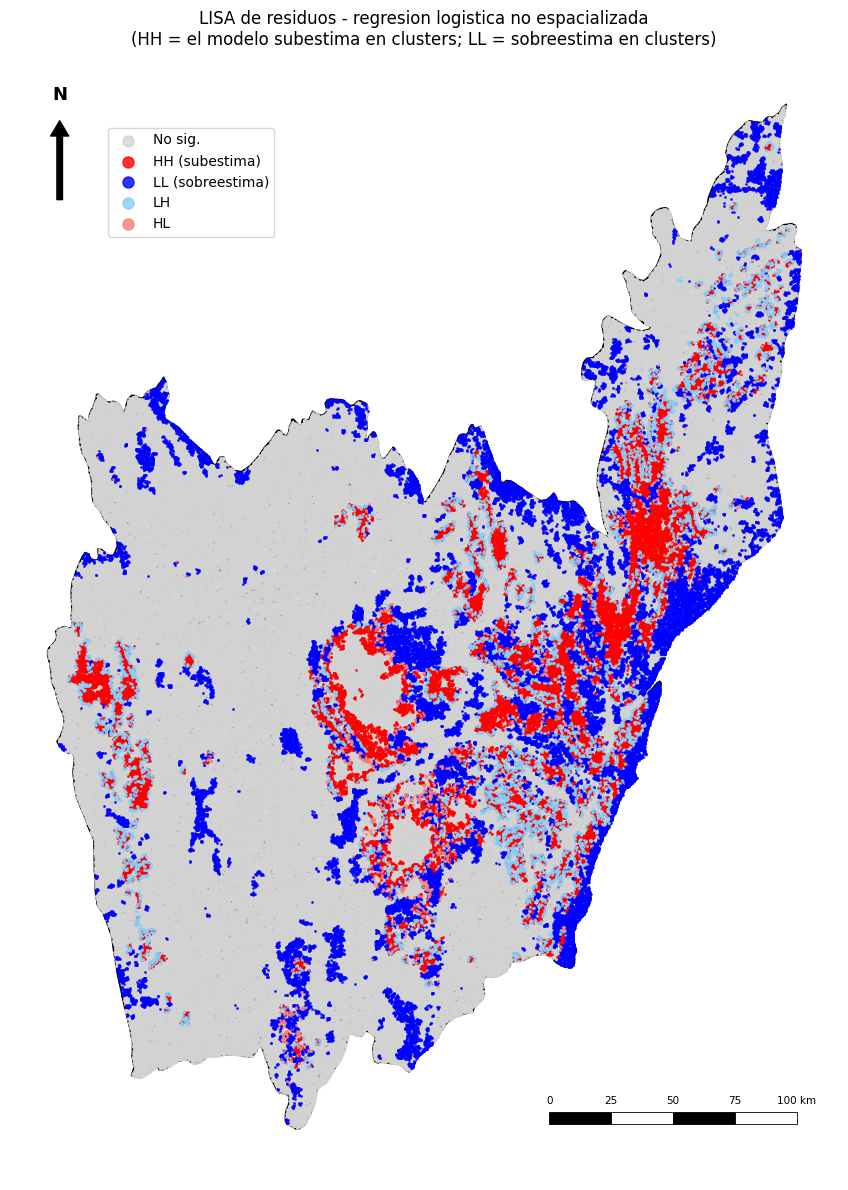

In [21]:
fig, ax = plt.subplots(figsize=(10, 12))
ancla = aplicar_plantilla_mapa(ax)

for categoria, color in colores.items():
    mask_cat = etiqueta == categoria
    ax.scatter(muestra["X"].values[mask_cat], muestra["Y"].values[mask_cat],
               s=1, c=color, label=categoria, alpha=0.8, zorder=5)

ax.set_title("LISA de residuos - regresion logistica no espacializada\n"
             "(HH = el modelo subestima en clusters; LL = sobreestima en clusters)")
ax.set_axis_off()
ax.legend(markerscale=8, **posicionar_leyenda(ax, ancla))
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_IMAGENES_NB, "05_lisa_residuos_raster.png"), dpi=150)
plt.show()


## [B6] Exportar capa de respaldo (Parte B)


In [22]:
geometria_puntos = gpd.points_from_xy(muestra["X"], muestra["Y"])
gdf_residuos = gpd.GeoDataFrame(muestra.drop(columns=["X", "Y"]), geometry=geometria_puntos, crs=ref_crs)

ruta_backup_b = os.path.join(CARPETA_RESULTADOS, "residuos_raster_lisa_muestra_v2.gpkg")
gdf_residuos.to_file(ruta_backup_b, driver="GPKG")
print(f"Backup Parte B guardado en: {ruta_backup_b}  ({len(gdf_residuos):,} puntos)")
print(f"\nTIEMPO TOTAL DEL NOTEBOOK: {time.time()-t0:.1f}s")


Backup Parte B guardado en: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\residuos_raster_lisa_muestra_v2.gpkg  (300,000 puntos)

TIEMPO TOTAL DEL NOTEBOOK: 118.2s


## Conclusiones

- **Parte A:** los 491 altiplanos muestran autocorrelación espacial fuerte y significativa
  en su morfometría (Moran's I de ~0.48 a ~0.92 según la variable), y el análisis LISA
  identifica más de la mitad de los polígonos como parte de un clúster local significativo.
- **Parte B:** los residuos del modelo de regresión logística NO espacializado muestran
  autocorrelación espacial positiva y significativa, confirmando que el modelo deja
  estructura geográfica sin explicar. Esto **no invalida** las métricas de predicción ya
  reportadas (AUC=0.9522), pero motiva evaluar un modelo espacial (`10_SAR`) como trabajo
  futuro — ver el análisis de factibilidad al cierre de esta etapa de regeneración.
